In [25]:
import os
import pandas as pd
import numpy as np


In [26]:
DATA_PATH = r"C:\Users\agraj\training_setA"


In [27]:
files = os.listdir(DATA_PATH)
print("Number of patient files:", len(files))
print("First 5 files:", files[:5])


Number of patient files: 20336
First 5 files: ['p000001.psv', 'p000002.psv', 'p000003.psv', 'p000004.psv', 'p000005.psv']


In [28]:
sample_file = files[0]
df = pd.read_csv(os.path.join(DATA_PATH, sample_file), sep="|")

df.head()


,HR,O2Sat,Temp,SBP,MAP,DBP,Resp,EtCO2,BaseExcess,HCO3,...,WBC,Fibrinogen,Platelets,Age,Gender,Unit1,Unit2,HospAdmTime,ICULOS,SepsisLabel
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,83.14,0,NaN,NaN,-0.03,1,0
1,97.0,95.0,NaN,98.0,75.33,NaN,19.0,NaN,NaN,NaN,...,NaN,NaN,NaN,83.14,0,NaN,NaN,-0.03,2,0
2,89.0,99.0,NaN,122.0,86.00,NaN,22.0,NaN,NaN,NaN,...,NaN,NaN,NaN,83.14,0,NaN,NaN,-0.03,3,0
3,90.0,95.0,NaN,NaN,NaN,NaN,30.0,NaN,24.0,NaN,...,NaN,NaN,NaN,83.14,0,NaN,NaN,-0.03,4,0
4,103.0,88.5,NaN,122.0,91.33,NaN,24.5,NaN,NaN,NaN,...,NaN,NaN,NaN,83.14,0,NaN,NaN,-0.03,5,0


In [29]:
def create_future_label(df, horizon_hours):
    df = df.copy()
    df['SepsisFutureLabel'] = 0

    sepsis_onset = df.index[df['SepsisLabel'] == 1]

    if len(sepsis_onset) > 0:
        onset_time = sepsis_onset[0]
        start_time = max(0, onset_time - horizon_hours)
        df.loc[start_time:onset_time - 1, 'SepsisFutureLabel'] = 1

    return df


In [30]:
df_12h = create_future_label(df, horizon_hours=12)
df_12h[['SepsisLabel', 'SepsisFutureLabel']].head(25)


,SepsisLabel,SepsisFutureLabel
0,0,0
1,0,0
2,0,0
3,0,0
4,0,0
5,0,0
6,0,0
7,0,0
8,0,0
9,0,0


In [31]:
df_12h[['SepsisLabel', 'SepsisFutureLabel']].tail(25)


,SepsisLabel,SepsisFutureLabel
29,0,0
30,0,0
31,0,0
32,0,0
33,0,0
34,0,0
35,0,0
36,0,0
37,0,0
38,0,0


In [32]:
df['SepsisLabel'].sum()


np.int64(0)

In [33]:
for f in files:
    df_temp = pd.read_csv(os.path.join(DATA_PATH, f), sep="|")
    if df_temp['SepsisLabel'].sum() > 0:
        print("Septic patient found:", f)
        break


Septic patient found: p000009.psv


In [34]:
df = pd.read_csv(os.path.join(DATA_PATH, f), sep="|")
df_12h = create_future_label(df, horizon_hours=12)

df_12h[['SepsisLabel', 'SepsisFutureLabel']].tail(40)


,SepsisLabel,SepsisFutureLabel
218,0,0
219,0,0
220,0,0
221,0,0
222,0,0
223,0,0
224,0,0
225,0,0
226,0,0
227,0,0


In [35]:
df_clean = remove_post_sepsis(df_12h)

df_clean[['SepsisLabel', 'SepsisFutureLabel']].tail(20)



,SepsisLabel,SepsisFutureLabel
228,0,0
229,0,0
230,0,0
231,0,0
232,0,0
233,0,0
234,0,0
235,0,0
236,0,1
237,0,1


In [36]:
def remove_post_sepsis(df):
    """
    Removes all rows after sepsis onset to prevent data leakage.
    """
    df = df.copy()
    if df['SepsisLabel'].sum() > 0:
        onset_time = df.index[df['SepsisLabel'] == 1][0]
        df = df.loc[:onset_time - 1]
    return df


In [37]:
df_clean = remove_post_sepsis(df_12h)
df_clean[['SepsisLabel', 'SepsisFutureLabel']].tail(20)


,SepsisLabel,SepsisFutureLabel
228,0,0
229,0,0
230,0,0
231,0,0
232,0,0
233,0,0
234,0,0
235,0,0
236,0,1
237,0,1


In [38]:
df_clean['SepsisLabel'].sum()


np.int64(0)

In [39]:
import os
import pandas as pd
import numpy as np

# -------- Label creation --------
def create_future_label(df, horizon_hours):
    df = df.copy()
    df['SepsisFutureLabel'] = 0

    sepsis_onset = df.index[df['SepsisLabel'] == 1]

    if len(sepsis_onset) > 0:
        onset_time = sepsis_onset[0]
        start_time = max(0, onset_time - horizon_hours)
        df.loc[start_time:onset_time - 1, 'SepsisFutureLabel'] = 1

    return df


# -------- Remove post-sepsis data --------
def remove_post_sepsis(df):
    df = df.copy()
    if df['SepsisLabel'].sum() > 0:
        onset_time = df.index[df['SepsisLabel'] == 1][0]
        df = df.loc[:onset_time - 1]
    return df


# -------- Preprocessing --------
DROP_COLS = [
    'SepsisLabel',
    'SepsisFutureLabel',
    'ICULOS',
    'HospAdmTime',
    'Unit1',
    'Unit2'
]

def preprocess_patient(df):
    df = df.copy()
    feature_cols = [c for c in df.columns if c not in DROP_COLS]
    df[feature_cols] = df[feature_cols].fillna(method='ffill')
    return df


# -------- Dataset preparation --------
def prepare_dataset(files, horizon, data_path):
    X_list, y_list = [], []

    for f in files:
        df = pd.read_csv(os.path.join(data_path, f), sep="|")

        df = create_future_label(df, horizon)
        df = remove_post_sepsis(df)
        df = preprocess_patient(df)

        feature_cols = [c for c in df.columns if c not in DROP_COLS]
        X_list.append(df[feature_cols])
        y_list.append(df['SepsisFutureLabel'])

    X = pd.concat(X_list)
    y = pd.concat(y_list)

    return X, y


In [40]:
files = os.listdir(DATA_PATH)

X_12h, y_12h = prepare_dataset(
    files[:500],
    horizon=12,
    data_path=DATA_PATH
)

print(X_12h.shape)
print(y_12h.value_counts())


C:\Users\agraj\AppData\Local\Temp\ipykernel_4892\1015639417.py:42: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df[feature_cols] = df[feature_cols].fillna(method='ffill')
C:\Users\agraj\AppData\Local\Temp\ipykernel_4892\1015639417.py:42: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df[feature_cols] = df[feature_cols].fillna(method='ffill')
C:\Users\agraj\AppData\Local\Temp\ipykernel_4892\1015639417.py:42: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df[feature_cols] = df[feature_cols].fillna(method='ffill')
C:\Users\agraj\AppData\Local\Temp\ipykernel_4892\1015639417.py:42: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df[

(18992, 36)
SepsisFutureLabel
0    18573
1      419
Name: count, dtype: int64


In [41]:
missing_fraction = X_12h.isna().mean()
missing_fraction.sort_values(ascending=False).head(10)


EtCO2               1.000000
Bilirubin_direct    0.968513
TroponinI           0.964669
Fibrinogen          0.867260
Bilirubin_total     0.763585
Alkalinephos        0.759004
AST                 0.756476
Lactate             0.633688
SaO2                0.632003
PaCO2               0.393692
dtype: float64

In [42]:
X_12h = X_12h.drop(columns=['EtCO2'])


In [43]:
print(X_12h.shape)


(18992, 35)


In [44]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy="median")
X_imputed = imputer.fit_transform(X_12h)


In [45]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_imputed,
    y_12h,
    test_size=0.2,
    random_state=42,
    stratify=y_12h
)


In [46]:
from sklearn.linear_model import LogisticRegression

log_reg = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    solver="liblinear"
)

log_reg.fit(X_train, y_train)


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,None
,solver,'liblinear'
,max_iter,1000
,multi_class,'deprecated'


In [47]:
from sklearn.metrics import roc_auc_score, average_precision_score

y_pred_proba = log_reg.predict_proba(X_test)[:, 1]

auroc = roc_auc_score(y_test, y_pred_proba)
auprc = average_precision_score(y_test, y_pred_proba)

print("AUROC (12h):", round(auroc, 3))
print("AUPRC (12h):", round(auprc, 3))


AUROC (12h): 0.854
AUPRC (12h): 0.082


In [48]:
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, average_precision_score

def train_evaluate_horizon(files, horizon, data_path):
    
    # Prepare dataset
    X, y = prepare_dataset(files[:500], horizon=horizon, data_path=data_path)
    
    # Drop fully missing column if present
    X = X.drop(columns=['EtCO2'], errors='ignore')
    
    # Impute
    imputer = SimpleImputer(strategy="median")
    X_imputed = imputer.fit_transform(X)
    
    # Train-test split
    X_train, X_test, y_train, y_test = train_test_split(
        X_imputed,
        y,
        test_size=0.2,
        random_state=42,
        stratify=y
    )
    
    # Logistic Regression
    model = LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        solver="liblinear"
    )
    
    model.fit(X_train, y_train)
    
    y_pred_proba = model.predict_proba(X_test)[:, 1]
    
    auroc = roc_auc_score(y_test, y_pred_proba)
    auprc = average_precision_score(y_test, y_pred_proba)
    
    return round(auroc, 3), round(auprc, 3)


In [49]:
files = os.listdir(DATA_PATH)

results = {}

for h in [6, 12, 24]:
    auroc, auprc = train_evaluate_horizon(files, h, DATA_PATH)
    results[h] = {"AUROC": auroc, "AUPRC": auprc}
    print(f"{h}h → AUROC: {auroc}, AUPRC: {auprc}")


C:\Users\agraj\AppData\Local\Temp\ipykernel_4892\1015639417.py:42: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df[feature_cols] = df[feature_cols].fillna(method='ffill')
C:\Users\agraj\AppData\Local\Temp\ipykernel_4892\1015639417.py:42: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df[feature_cols] = df[feature_cols].fillna(method='ffill')
C:\Users\agraj\AppData\Local\Temp\ipykernel_4892\1015639417.py:42: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df[feature_cols] = df[feature_cols].fillna(method='ffill')
C:\Users\agraj\AppData\Local\Temp\ipykernel_4892\1015639417.py:42: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df[

6h → AUROC: 0.876, AUPRC: 0.062


C:\Users\agraj\AppData\Local\Temp\ipykernel_4892\1015639417.py:42: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df[feature_cols] = df[feature_cols].fillna(method='ffill')
C:\Users\agraj\AppData\Local\Temp\ipykernel_4892\1015639417.py:42: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df[feature_cols] = df[feature_cols].fillna(method='ffill')
C:\Users\agraj\AppData\Local\Temp\ipykernel_4892\1015639417.py:42: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df[feature_cols] = df[feature_cols].fillna(method='ffill')
C:\Users\agraj\AppData\Local\Temp\ipykernel_4892\1015639417.py:42: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df[

12h → AUROC: 0.854, AUPRC: 0.082


C:\Users\agraj\AppData\Local\Temp\ipykernel_4892\1015639417.py:42: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df[feature_cols] = df[feature_cols].fillna(method='ffill')
C:\Users\agraj\AppData\Local\Temp\ipykernel_4892\1015639417.py:42: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df[feature_cols] = df[feature_cols].fillna(method='ffill')
C:\Users\agraj\AppData\Local\Temp\ipykernel_4892\1015639417.py:42: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df[feature_cols] = df[feature_cols].fillna(method='ffill')
C:\Users\agraj\AppData\Local\Temp\ipykernel_4892\1015639417.py:42: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df[

24h → AUROC: 0.85, AUPRC: 0.161


In [50]:
auroc_6h, auprc_6h = train_evaluate_horizon(
    files,
    horizon=6,
    data_path=DATA_PATH
)

print("6h → AUROC:", auroc_6h, "AUPRC:", auprc_6h)


C:\Users\agraj\AppData\Local\Temp\ipykernel_4892\1015639417.py:42: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df[feature_cols] = df[feature_cols].fillna(method='ffill')
C:\Users\agraj\AppData\Local\Temp\ipykernel_4892\1015639417.py:42: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df[feature_cols] = df[feature_cols].fillna(method='ffill')
C:\Users\agraj\AppData\Local\Temp\ipykernel_4892\1015639417.py:42: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df[feature_cols] = df[feature_cols].fillna(method='ffill')
C:\Users\agraj\AppData\Local\Temp\ipykernel_4892\1015639417.py:42: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df[

6h → AUROC: 0.876 AUPRC: 0.062


In [51]:
auroc_12h, auprc_12h = train_evaluate_horizon(
    files,
    horizon=12,
    data_path=DATA_PATH
)

print("12h → AUROC:", auroc_12h, "AUPRC:", auprc_12h)

C:\Users\agraj\AppData\Local\Temp\ipykernel_4892\1015639417.py:42: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df[feature_cols] = df[feature_cols].fillna(method='ffill')
C:\Users\agraj\AppData\Local\Temp\ipykernel_4892\1015639417.py:42: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df[feature_cols] = df[feature_cols].fillna(method='ffill')
C:\Users\agraj\AppData\Local\Temp\ipykernel_4892\1015639417.py:42: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df[feature_cols] = df[feature_cols].fillna(method='ffill')
C:\Users\agraj\AppData\Local\Temp\ipykernel_4892\1015639417.py:42: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df[

12h → AUROC: 0.854 AUPRC: 0.082


In [52]:
auroc_24h, auprc_24h = train_evaluate_horizon(
    files,
    horizon=24,
    data_path=DATA_PATH
)

print("24h → AUROC:", auroc_24h, "AUPRC:", auprc_24h)


C:\Users\agraj\AppData\Local\Temp\ipykernel_4892\1015639417.py:42: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df[feature_cols] = df[feature_cols].fillna(method='ffill')
C:\Users\agraj\AppData\Local\Temp\ipykernel_4892\1015639417.py:42: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df[feature_cols] = df[feature_cols].fillna(method='ffill')
C:\Users\agraj\AppData\Local\Temp\ipykernel_4892\1015639417.py:42: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df[feature_cols] = df[feature_cols].fillna(method='ffill')
C:\Users\agraj\AppData\Local\Temp\ipykernel_4892\1015639417.py:42: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df[

24h → AUROC: 0.85 AUPRC: 0.161


In [ ]:
MODEL COMPARISON (12-Hour Horizon) as below

In [55]:
def prepare_dataset(files, horizon, data_path):
    X_list, y_list, pid_list = [], [], []

    for pid, f in enumerate(files):
        df = pd.read_csv(os.path.join(data_path, f), sep="|")

        df = create_future_label(df, horizon)
        df = remove_post_sepsis(df)
        df = preprocess_patient(df)

        feature_cols = [c for c in df.columns if c not in DROP_COLS]

        X_list.append(df[feature_cols])
        y_list.append(df['SepsisFutureLabel'])
        pid_list.append(pd.Series(pid, index=df.index))

    X = pd.concat(X_list).reset_index(drop=True)
    y = pd.concat(y_list).reset_index(drop=True)
    patient_ids = pd.concat(pid_list).reset_index(drop=True)

    return X, y, patient_ids



In [56]:
X_12h, y_12h, patient_ids = prepare_dataset(
    files[:500],
    horizon=12,
    data_path=DATA_PATH
)

X_12h = X_12h.drop(columns=['EtCO2'], errors='ignore')


C:\Users\agraj\AppData\Local\Temp\ipykernel_4892\1015639417.py:42: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df[feature_cols] = df[feature_cols].fillna(method='ffill')
C:\Users\agraj\AppData\Local\Temp\ipykernel_4892\1015639417.py:42: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df[feature_cols] = df[feature_cols].fillna(method='ffill')
C:\Users\agraj\AppData\Local\Temp\ipykernel_4892\1015639417.py:42: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df[feature_cols] = df[feature_cols].fillna(method='ffill')
C:\Users\agraj\AppData\Local\Temp\ipykernel_4892\1015639417.py:42: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df[

In [57]:
from sklearn.model_selection import GroupShuffleSplit

gss = GroupShuffleSplit(
    test_size=0.2,
    random_state=42
)

train_idx, test_idx = next(gss.split(X_12h, y_12h, groups=patient_ids))

X_train = X_12h.iloc[train_idx]
X_test = X_12h.iloc[test_idx]
y_train = y_12h.iloc[train_idx]
y_test = y_12h.iloc[test_idx]


In [58]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy="median")

X_train_imp = imputer.fit_transform(X_train)
X_test_imp = imputer.transform(X_test)


In [59]:
rf_model = RandomForestClassifier(
    n_estimators=200,
    min_samples_leaf=5,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train_imp, y_train)

y_pred_rf = rf_model.predict_proba(X_test_imp)[:, 1]

rf_auroc = roc_auc_score(y_test, y_pred_rf)
rf_auprc = average_precision_score(y_test, y_pred_rf)

print("RF (12h) AUROC:", round(rf_auroc, 3))
print("RF (12h) AUPRC:", round(rf_auprc, 3))


RF (12h) AUROC: 0.684
RF (12h) AUPRC: 0.025


In [ ]:
EXPLAINABILITY — LOGISTIC REGRESSION

In [60]:
from sklearn.linear_model import LogisticRegression

log_reg = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    solver="liblinear"
)

log_reg.fit(X_train_imp, y_train)



,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,None
,solver,'liblinear'
,max_iter,1000
,multi_class,'deprecated'


In [61]:
import pandas as pd
import numpy as np

feature_names = X_12h.columns

coef_df = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": log_reg.coef_[0]
})

# Absolute importance
coef_df["AbsCoeff"] = coef_df["Coefficient"].abs()

coef_df = coef_df.sort_values("AbsCoeff", ascending=False)

coef_df.head(10)


,Feature,Coefficient,AbsCoeff
10,pH,-6.053988,6.053988
9,FiO2,2.294693,2.294693
22,Magnesium,1.805486,1.805486
21,Lactate,-0.799171,0.799171
2,Temp,0.556737,0.556737
34,Gender,-0.524662,0.524662
28,Hgb,-0.492849,0.492849
26,TroponinI,-0.421296,0.421296
24,Potassium,-0.375799,0.375799
16,Calcium,-0.299956,0.299956


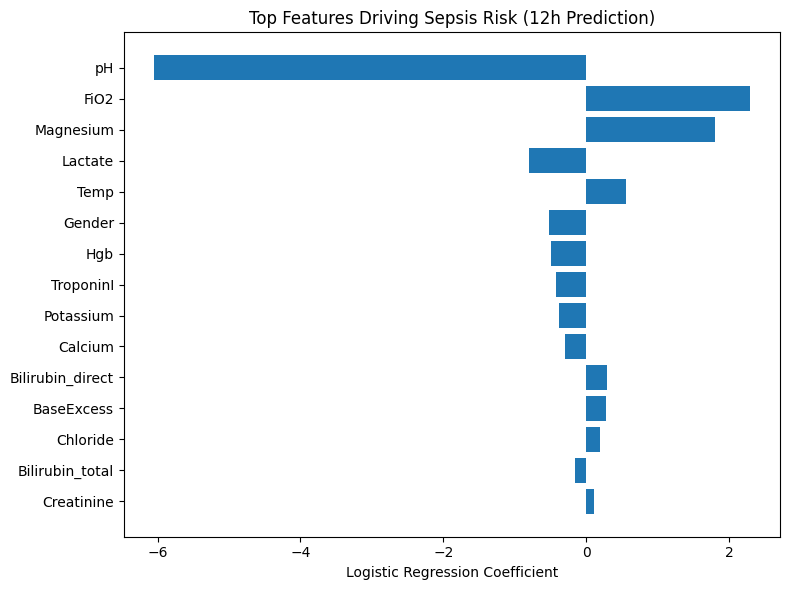

In [62]:
import matplotlib.pyplot as plt

top_n = 15
top_features = coef_df.head(top_n)

plt.figure(figsize=(8, 6))
plt.barh(
    top_features["Feature"][::-1],
    top_features["Coefficient"][::-1]
)
plt.xlabel("Logistic Regression Coefficient")
plt.title("Top Features Driving Sepsis Risk (12h Prediction)")
plt.tight_layout()
plt.show()


In [64]:
from sklearn.linear_model import LogisticRegression
from sklearn.impute import SimpleImputer
from sklearn.model_selection import GroupShuffleSplit
import pandas as pd

def get_top_features_for_horizon(horizon):
    # Prepare dataset
    X, y, pids = prepare_dataset(
        files[:500],
        horizon=horizon,
        data_path=DATA_PATH
    )

    # Drop fully missing feature
    X = X.drop(columns=['EtCO2'], errors='ignore')

    # Patient-level split
    gss = GroupShuffleSplit(test_size=0.2, random_state=42)
    train_idx, test_idx = next(gss.split(X, y, groups=pids))

    X_train = X.iloc[train_idx]
    y_train = y.iloc[train_idx]

    # Imputation
    imputer = SimpleImputer(strategy="median")
    X_train_imp = imputer.fit_transform(X_train)

    # Train logistic regression
    model = LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        solver="liblinear"
    )
    model.fit(X_train_imp, y_train)

    # Extract coefficients
    coef_df = pd.DataFrame({
        "Feature": X.columns,
        "Coefficient": model.coef_[0]
    })
    coef_df["AbsCoeff"] = coef_df["Coefficient"].abs()

    return coef_df.sort_values("AbsCoeff", ascending=False).head(10)



In [65]:
top_6h = get_top_features_for_horizon(6)
top_12h = get_top_features_for_horizon(12)
top_24h = get_top_features_for_horizon(24)

print("Top 5 features at 6h:\n", top_6h.head(5))
print("\nTop 5 features at 12h:\n", top_12h.head(5))
print("\nTop 5 features at 24h:\n", top_24h.head(5))



C:\Users\agraj\AppData\Local\Temp\ipykernel_4892\1015639417.py:42: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df[feature_cols] = df[feature_cols].fillna(method='ffill')
C:\Users\agraj\AppData\Local\Temp\ipykernel_4892\1015639417.py:42: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df[feature_cols] = df[feature_cols].fillna(method='ffill')
C:\Users\agraj\AppData\Local\Temp\ipykernel_4892\1015639417.py:42: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df[feature_cols] = df[feature_cols].fillna(method='ffill')
C:\Users\agraj\AppData\Local\Temp\ipykernel_4892\1015639417.py:42: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df[

Top 5 features at 6h:
              Feature  Coefficient  AbsCoeff
10                pH    -6.814530  6.814530
9               FiO2     3.001173  3.001173
22         Magnesium     1.694010  1.694010
21           Lactate    -0.909516  0.909516
19  Bilirubin_direct     0.801795  0.801795

Top 5 features at 12h:
       Feature  Coefficient  AbsCoeff
10         pH    -6.053988  6.053988
9        FiO2     2.294693  2.294693
22  Magnesium     1.805486  1.805486
21    Lactate    -0.799171  0.799171
2        Temp     0.556737  0.556737

Top 5 features at 24h:
       Feature  Coefficient  AbsCoeff
10         pH    -4.779259  4.779259
9        FiO2     1.597167  1.597167
22  Magnesium     1.397377  1.397377
21    Lactate    -0.548834  0.548834
28        Hgb    -0.399388  0.399388


In [ ]:
Figures

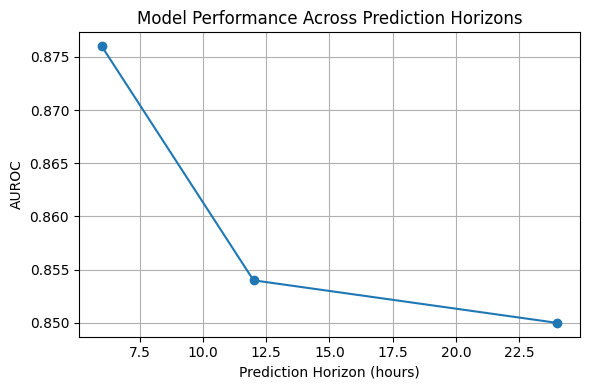

In [72]:
import matplotlib.pyplot as plt

horizons = [6, 12, 24]
auroc_values = [0.876, 0.854, 0.850]

plt.figure(figsize=(6, 4))
plt.plot(horizons, auroc_values, marker='o')
plt.xlabel("Prediction Horizon (hours)")
plt.ylabel("AUROC")
plt.title("Model Performance Across Prediction Horizons")
plt.grid(True)
plt.tight_layout()

# SAVE FIRST
plt.savefig("Model Performance Across Prediction Horizons.png", dpi=300, bbox_inches="tight")

# THEN SHOW
plt.show()


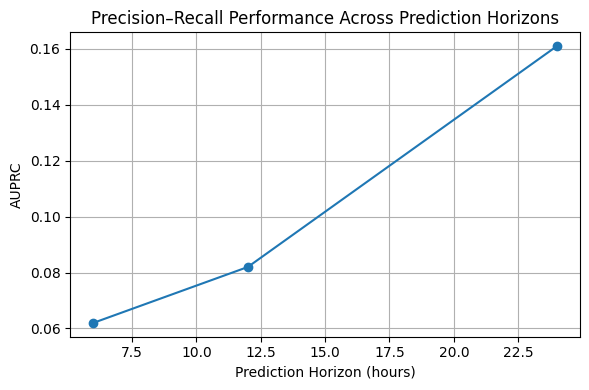

In [73]:
auprc_values = [0.062, 0.082, 0.161]

plt.figure(figsize=(6, 4))
plt.plot(horizons, auprc_values, marker='o')
plt.xlabel("Prediction Horizon (hours)")
plt.ylabel("AUPRC")
plt.title("Precision–Recall Performance Across Prediction Horizons")
plt.grid(True)
plt.tight_layout()
# SAVE FIRST
plt.savefig("Precision–Recall Performance Across Prediction Horizons.png", dpi=300, bbox_inches="tight")

# THEN SHOW
plt.show()

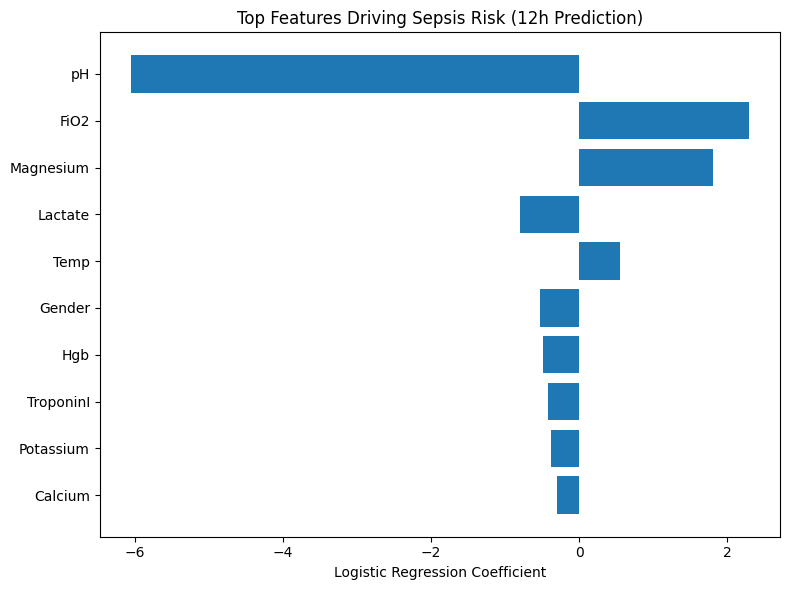

In [75]:
top_features_12h = top_12h.head(10)

plt.figure(figsize=(8, 6))
plt.barh(
    top_features_12h["Feature"][::-1],
    top_features_12h["Coefficient"][::-1]
)
plt.xlabel("Logistic Regression Coefficient")
plt.title("Top Features Driving Sepsis Risk (12h Prediction)")
plt.tight_layout()

# SAVE FIRST
plt.savefig("Top Features Driving Sepsis Risk (12h Prediction).png", dpi=300, bbox_inches="tight")

# THEN SHOW
plt.show()


In [69]:
feature_table = pd.DataFrame({
    "6h": top_6h["Feature"].values[:5],
    "12h": top_12h["Feature"].values[:5],
    "24h": top_24h["Feature"].values[:5]
})

feature_table


,6h,12h,24h
0,pH,pH,pH
1,FiO2,FiO2,FiO2
2,Magnesium,Magnesium,Magnesium
3,Lactate,Lactate,Lactate
4,Bilirubin_direct,Temp,Hgb
